<a href="https://colab.research.google.com/github/flapinski/SML/blob/main/proj/SML_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sc_st
import sklearn.linear_model as skl_lm
import sklearn.preprocessing as skl_pre
import statsmodels.api as sm
import copy

In [3]:
url = 'https://raw.githubusercontent.com/flapinski/SML/main/proj/train.csv'
df = pd.read_csv(url)
df

,Number words female,Total words,Number of words lead,Difference in words lead and co-lead,Number of male actors,Year,Number of female actors,Number words male,Gross,Mean Age Male,Mean Age Female,Age Lead,Age Co-Lead,Lead
0,1512,6394,2251.0,343,2,1995,5,2631,142.0,51.500000,42.333333,46.0,65.0,Female
1,1524,8780,2020.0,1219,9,2001,4,5236,37.0,39.125000,29.333333,58.0,34.0,Male
2,155,4176,942.0,787,7,1968,1,3079,376.0,42.500000,37.000000,46.0,37.0,Male
3,1073,9855,3440.0,2623,12,2002,2,5342,19.0,35.222222,21.500000,33.0,23.0,Male
4,1317,7688,3835.0,3149,8,1988,4,2536,40.0,45.250000,45.000000,36.0,39.0,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1034,303,2398,1334.0,1166,5,1973,2,761,174.0,43.200000,31.000000,46.0,24.0,Male
1035,632,8404,1952.0,187,6,1992,2,5820,172.0,37.166667,24.000000,21.0,34.0,Female
1036,1326,2750,877.0,356,2,2000,3,547,53.0,27.500000,27.666667,28.0,25.0,Male
1037,462,3994,775.0,52,8,1996,3,2757,32.0,42.857143,38.500000,29.0,32.0,Female


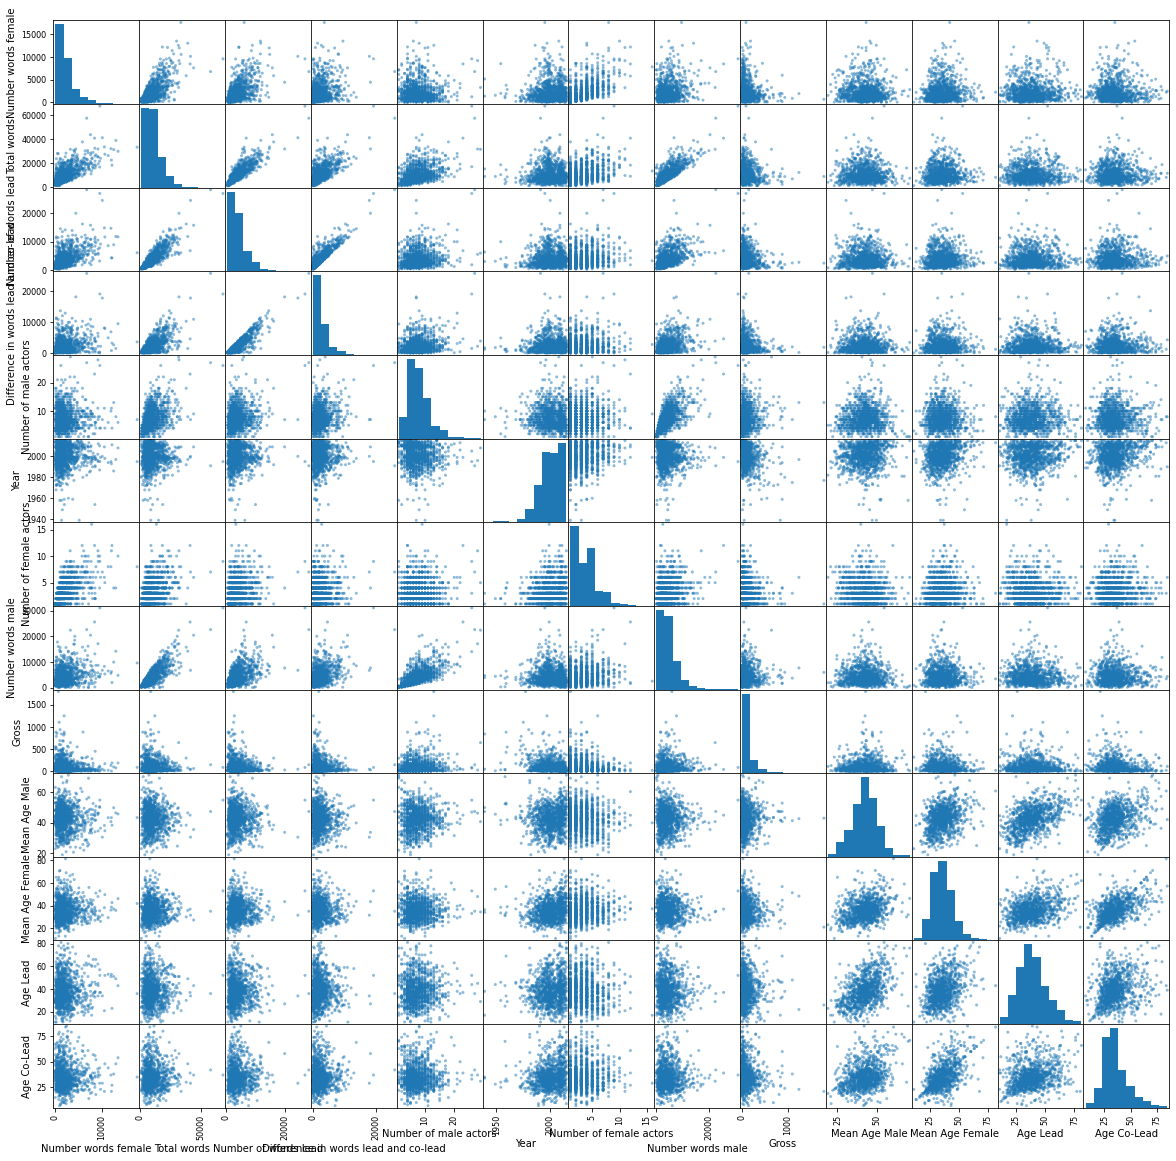

In [4]:
pd.plotting.scatter_matrix(df.iloc[:, 0:-1], figsize = (20,20))
plt.show()

(0.31031449652053983, 0.33571262502109805)




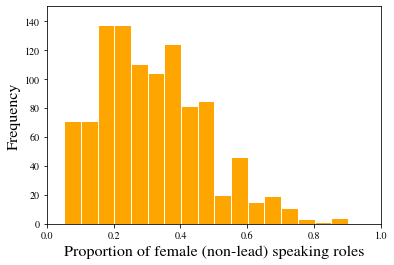

In [10]:
x = df['Number of female actors']/(df['Number of female actors'] + df['Number of male actors'])
N = len(x)

mu = np.mean(x)
sd = np.sqrt(np.var(x, ddof = 1))

ci = sc_st.norm.interval(0.99, mu, sd/np.sqrt(N))
print(ci)
print('\n')

plt.hist(x, bins=17, color= 'orange', edgecolor='w')
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.xlabel('Proportion of female (non-lead) speaking roles', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.xlim([0,1])
plt.ylim([0,150])

#plt.title(r'ABC123 vs $\mathrm{ABC123}^{123}$')
plt.show()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     6.888
Date:                Tue, 22 Nov 2022   Prob (F-statistic):             0.0115
Time:                        13:44:14   Log-Likelihood:                 71.968
No. Observations:                  51   AIC:                            -139.9
Df Residuals:                      49   BIC:                            -136.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1414      0.934     -2.293      0.0

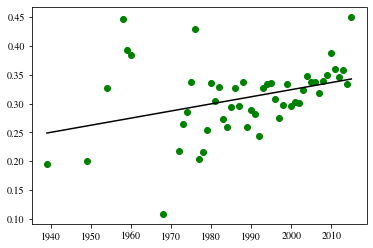

In [11]:
df2 = df.sort_values('Year').loc[:, ['Year', 'Number of male actors', 'Number of female actors']]
df2['Prop. of female speaking roles'] = df2['Number of female actors']/(df2['Number of male actors']+df2['Number of female actors'])
df3 = df2.groupby('Year').mean()
year = df3.index.array
prop = np.asarray(df3['Prop. of female speaking roles'])

m = skl_lm.LinearRegression().fit(year.reshape(-1,1), prop.reshape(-1,1))
pred = m.predict(year.reshape(-1,1))

plt.plot(year, prop, 'o', color = 'g')
plt.plot(year, pred, color = 'black')

####
x = sm.add_constant(year)
y = prop.reshape(-1,1)
model = sm.OLS(y, x).fit()
print(model.summary())    # P(slope=0) = 0.012 < 0.05 --> can reject the hypothesis that the slope is zero


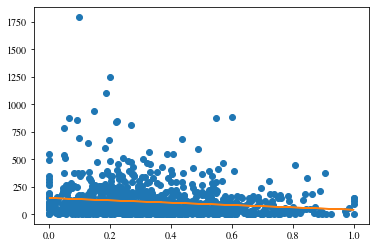

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     23.08
Date:                Tue, 22 Nov 2022   Prob (F-statistic):           1.78e-06
Time:                        13:44:41   Log-Likelihood:                -6680.5
No. Observations:                1039   AIC:                         1.337e+04
Df Residuals:                    1037   BIC:                         1.337e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        147.9316      8.962     16.507      0.0

In [12]:
prop = np.asarray(df['Number words female']/(df['Number words male']+df['Number words female'])).reshape(-1,1)
gross = np.asarray(df['Gross']).reshape(-1,1)

m = skl_lm.LinearRegression().fit(prop, gross)
y = m.predict(prop)

plt.plot(prop, gross, 'o')
plt.plot(prop, y)
plt.show()

####
x = sm.add_constant(prop)
y = gross
model = sm.OLS(y, x).fit()
print(model.summary())    # P(slope=0) = 0.00 < 0.05 --> can reject the hypothesis that the slope is zero


In [147]:
# Columns.  0 = # words f       1 = # words         2 = # words lead,
#           3 = diffwrds l/cl   4 = # male actors   5 = year,
#           6 = # fe actors     7 = # words male    8 = gross
#           9 = mean age m      10 = mean age f     11 = age l
#           12 = age cl         13 = lead

# Test: Explain one feature with the other features --> 0,1,2,7 (words f, words, words l, words m) can be perfectly explained by eachother
i = 8
col = [0,1,2,3,4,5,6,7,8,9,10,11,12]
col.remove(i)
X = df.iloc[:,col]
y = df.iloc[:,i]
mgr = skl_lm.LinearRegression().fit(X,y)
grp = mgr.predict(X)
mgr.score(X, y)

0.11581478494099784

In [133]:
# Tests for removing one feature
col = [0,1,2,3,4,5,6,7,8,9,10,11,12]
score = []
for i in range(13):
  col_del = copy.deepcopy(col)
  col_del.remove(i)
  X = df.iloc[:,col_del]
  y = df.iloc[:,-1]
  scaler = skl_pre.StandardScaler().fit(X)
  Xsc = scaler.transform(X)
  m = skl_lm.LogisticRegression(solver='lbfgs')
  m.fit(Xsc, y)
  yp = m.predict(Xsc)
  score.append(np.mean(yp == y))

X = df.iloc[:,col]
y = df.iloc[:,-1]
scaler = skl_pre.StandardScaler().fit(X)
Xsc = scaler.transform(X)
m = skl_lm.LogisticRegression(solver='lbfgs')
m.fit(Xsc, y)
yp = m.predict(Xsc)
score_all = np.mean(yp == y)
print(score_all)
print(score_all-score)  # how much the score is lowered when feature i is removed



0.87776708373436
[0.01443696 0.         0.00769971 0.02983638 0.03079885 0.
 0.06256015 0.         0.         0.00384986 0.00192493 0.01636189
 0.00288739]


In [141]:
print(min(df.iloc[:,8]))

0.0


In [162]:
# Features 1,5,7,8 do not lower score at all when removed. Try removing several:
col = [0,1,2,3,4,5,6,7,8,9,10,11,12]
col.remove(8)
col.remove(5)
col.remove(1)
col.remove(0)

col.remove(6) # # f actors
col.remove(4) # # m actors

col.remove(9)  # mean age male 
col.remove(10)  # mean age female
col.remove(11)  # age lead

X = df.iloc[:,col]
#X['grosslog'] = np.log(df.iloc[:,8]+1)
X['fwordsprop'] = df.iloc[:,0]/df.iloc[:,1]
X['factorsprop'] = df.iloc[:,6]/(df.iloc[:,4] + df.iloc[:,6])
y = df.iloc[:,-1]
scaler = skl_pre.StandardScaler().fit(X)
Xsc = scaler.transform(X)
m = skl_lm.LogisticRegression(solver='lbfgs')
m.fit(Xsc, y)
yp = m.predict(Xsc)
score_all = np.mean(yp == y)
print(score_all)

0.8893166506256015


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del sys.path[0]
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
